In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import sys
sys.path.insert(0, "/home/wfrederick/project1ml4h/libs")

from umap import UMAP
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

/home/wfrederick/project1ml4h/libs/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
test_embeddings = np.load("test_embeddings.npy")
test_labels     = np.load("test_labels.npy")
cluster_labels  = np.load("cluster_labels.npy")

print(f"Embeddings shape: {test_embeddings.shape}")
print(f"Labels shape:     {test_labels.shape}")
print(f"Cluster labels:   {cluster_labels.shape}")

Embeddings shape: (4000, 4096)
Labels shape:     (4000,)
Cluster labels:   (4000,)


In [3]:
print("Running UMAP...")
reducer = UMAP(n_components=2, random_state=42)
umap_reduced = reducer.fit_transform(test_embeddings)
print(f"UMAP output shape: {umap_reduced.shape}")

Running UMAP...


/home/wfrederick/project1ml4h/libs/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (4000, 2)


In [4]:
print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_reduced = tsne.fit_transform(test_embeddings)
print(f"t-SNE output shape: {tsne_reduced.shape}")

Running t-SNE...
t-SNE output shape: (4000, 2)


In [9]:
import matplotlib.pyplot as plt
import numpy as np

def plot_embeddings(reduced, cluster_labels, true_labels, method):
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))

    # Colors consistent with your other script
    colours = {0: "#3b82f6", 1: "#ef4444"}  # blue=alive, red=dead
    names = {0: "Alive", 1: "Dead"}

    true_labels = np.asarray(true_labels).astype(int)

    for c in [0, 1]:
        mask = true_labels == c
        ax.scatter(
            reduced[mask, 0],
            reduced[mask, 1],
            c=colours[c],
            label=names[c],
            s=8,
            alpha=0.5,
            edgecolors="none",
        )

    ax.set_title(f"{method} Embeddings — Mortality Label")
    ax.set_xlabel(f"{method} 1")
    ax.set_ylabel(f"{method} 2")

    ax.legend(markerscale=3, frameon=True)

    # Clean axes (like your reference style)
    ax.set_xticks([])
    ax.set_yticks([])

    fig.tight_layout()

    plt.savefig(
        f"{method.lower().replace('-', '_')}_embeddings.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

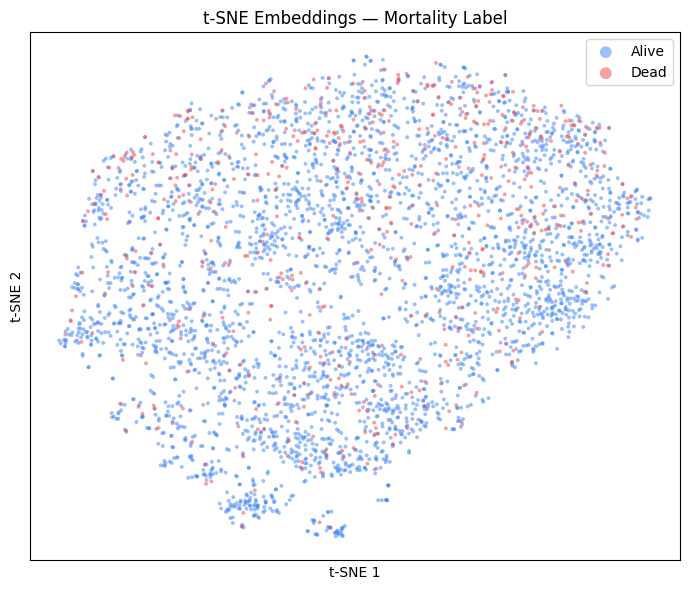

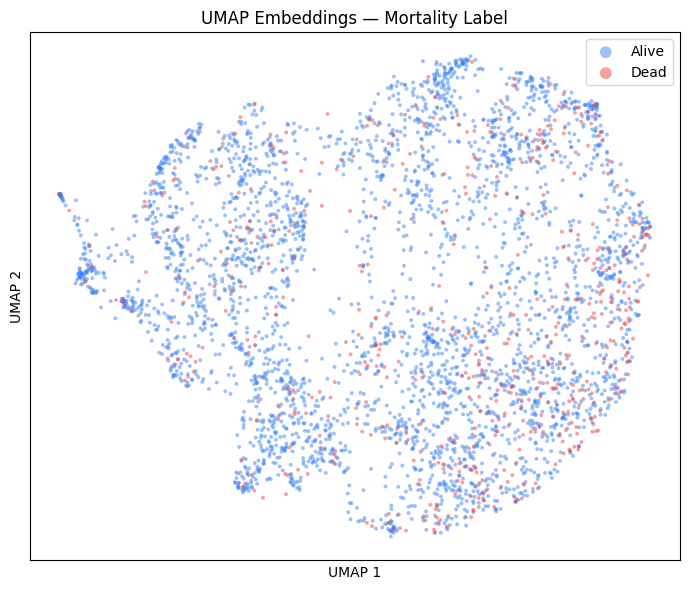

In [10]:
plot_embeddings(tsne_reduced, cluster_labels, test_labels, "t-SNE")
plot_embeddings(umap_reduced, cluster_labels, test_labels, "UMAP")